# 膜性能劣化の感度 — Q_A / alpha → 回収率・生産量・TAC

**狙い**: 膜の C3H6 permeance $Q_A$=40 GPU と 選択率 $\alpha$=90 は **!仮置き(Hua et al. 2024 文献値)**。
実機では可塑化・混合効果で劣化しうる。本ノートは劣化係数 $f_{Q_A},f_\alpha$ を振り、
**C3H6 回収率↓ → リサイクル↑/生産量↓ → TAC/feasibility** がどう動くかを実走で示す(設計点 #201 固定)。

`run_one_pass` は `PDH_MEM_QA_FACTOR` / `PDH_MEM_ALPHA_FACTOR`(既定 1.0)を per-call で読むので、
os.environ を差し替えてから evaluate するだけで劣化を注入できる。⚠️ Dist2=HYSYS, VPN 必須・数分。


In [1]:
import os, sys, warnings, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
os.environ.setdefault('PDH_TRIAL_TIME_BUDGET_SEC', '300')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
import main
from flowsheet import evaluate
best = json.load(open(os.path.join(ROOT, 'outputs', 'main_20260605_170938', 'best.json'), encoding='utf-8'))
p = best['params']; main.REACTOR_KIND = 'catofin'
F_fresh = float(p['F_C3H8_fresh_kmol_h'])
print('設計点 #201 固定. 既定 Q_A=40 GPU, alpha=90 (factor=1.0 が文献値)')

def eval_mem(qa=1.0, al=1.0):
    o_qa = os.environ.get('PDH_MEM_QA_FACTOR'); o_al = os.environ.get('PDH_MEM_ALPHA_FACTOR')
    try:
        os.environ['PDH_MEM_QA_FACTOR'] = str(qa); os.environ['PDH_MEM_ALPHA_FACTOR'] = str(al)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r = evaluate(main._build_design(p), main._CONFIG, verbose=False, apply_hi=True,
                         hi_dT_min_K=10.0, apply_stage2=False, F_C3H8_override=F_fresh)
    finally:
        for k, v in (('PDH_MEM_QA_FACTOR', o_qa), ('PDH_MEM_ALPHA_FACTOR', o_al)):
            if v is None: os.environ.pop(k, None)
            else: os.environ[k] = v
    op = r.solver.one_pass if (r.solver and r.solver.one_pass) else {}
    mem = op.get('r_mem'); prod = r.specs.production_kmol_h if r.specs else float('nan')
    rec = None
    if mem and getattr(mem, 'product', None) and getattr(mem, 'retentate', None):
        c6p = mem.product.F_C3H6; c6r = mem.retentate.F_C3H6
        rec = 100*c6p/(c6p+c6r) if (c6p+c6r) > 0 else None
    return dict(Q_A=qa, alpha=al, recovery=round(rec,1) if rec else None,
                prod=round(prod,0) if prod==prod else prod, eff_TAC=round(r.effective_TAC,1),
                feas=r.is_feasible, unit=r.failure_unit)

設計点 #201 固定. 既定 Q_A=40 GPU, alpha=90 (factor=1.0 が文献値)


## Q_A・alpha 劣化を振って実走

 Q_A  alpha  recovery   prod  eff_TAC  feas    unit
1.00    1.0      60.4 1194.0   1055.0  True success
0.85    1.0      50.5 1194.0   1063.9  True success
0.70    1.0      40.1 1194.0   1092.2  True success
1.00    0.7      59.7 1194.0   1057.4  True success


C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21252\1971249182.py:18: UserWarning: Glyph 33180 (\N{CJK UNIFIED IDEOGRAPH-819C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21252\1971249182.py:18: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21252\1971249182.py:18: UserWarning: Glyph 21454 (\N{CJK UNIFIED IDEOGRAPH-53CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21252\1971249182.py:18: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21252\1971249182.py:18: UserWarning: Glyph 20740 (\N{CJK UNIFIED IDEOGRAPH-5104}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


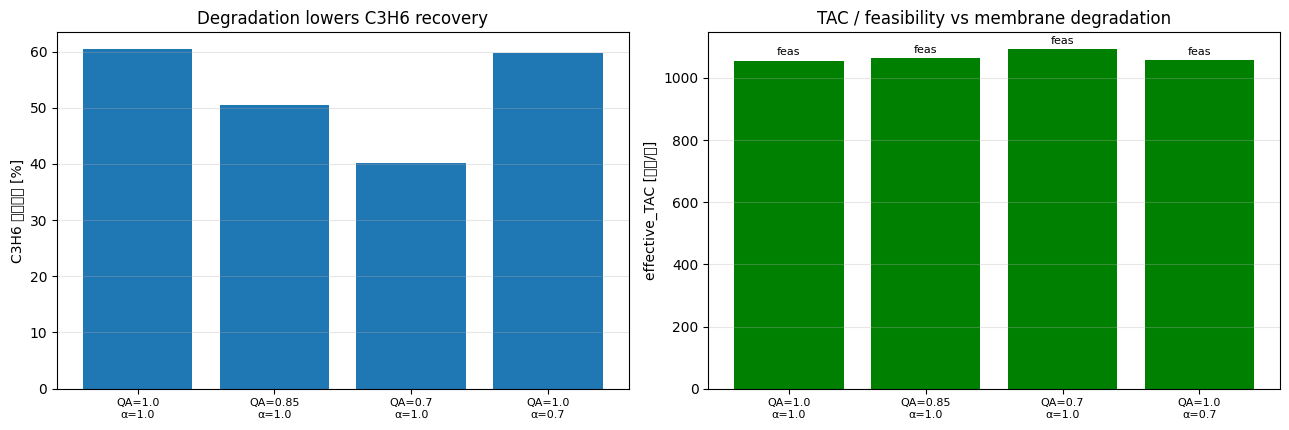

読み: Q_A/alpha 劣化で C3H6 回収率↓ → 製品が retentate(リサイクル)へ漏れ生産量↓ → TAC↑/不成立。


In [2]:
cases = [(1.0,1.0), (0.85,1.0), (0.7,1.0), (1.0,0.7)]
rows = [eval_mem(qa, al) for qa, al in cases]
df = pd.DataFrame(rows)
print(df.to_string(index=False))

labels = [f'QA={r.Q_A}\nα={r.alpha}' for _, r in df.iterrows()]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(df))
ax[0].bar(x, df['recovery'].fillna(0), color='C0')
ax[0].set_xticks(x); ax[0].set_xticklabels(labels, fontsize=8)
ax[0].set_ylabel('C3H6 膜回収率 [%]'); ax[0].set_title('Degradation lowers C3H6 recovery'); ax[0].grid(alpha=0.3, axis='y')
ax[1].bar(x, df['eff_TAC'], color=['green' if f else 'crimson' for f in df.feas])
for i, r in df.iterrows():
    ax[1].annotate('feas' if r.feas else r.unit, (i, r.eff_TAC), fontsize=8, ha='center',
                   xytext=(0,4), textcoords='offset points')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8)
ax[1].set_ylabel('effective_TAC [億円/年]'); ax[1].set_title('TAC / feasibility vs membrane degradation'); ax[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print('読み: Q_A/alpha 劣化で C3H6 回収率↓ → 製品が retentate(リサイクル)へ漏れ生産量↓ → TAC↑/不成立。')

## 結論

- 膜の $Q_A$/$\alpha$ は **!仮置き(文献値)**。劣化すると C3H6 回収率が下がり、製品が retentate(リサイクル)へ
  漏れて生産量が低下、TAC が上がる/spec を割る。
- 本ノートで「文献値からの劣化が TAC/feasibility をどれだけ脅かすか」を定量化した。レポートには膜性能の
  出典と、本感度幅(劣化マージン)を明記すべき。設計点を固定した純感度なので、各劣化で再最適化すれば
  真の頑健性(膜を大きくして回収を補う等)が出る。
